In [ ]:
from pathlib import Path
import openeo
import xarray as xr
import matplotlib.pyplot as plt
import imageio
import numpy as np
import os
from datetime import datetime, timedelta

# Setup paths
base_path = Path("results")
frames_dir = base_path / "frames"
base_path.mkdir(exist_ok=True)
frames_dir.mkdir(exist_ok=True)

# Connect and authenticate
eoconn = openeo.connect("openeo.dataspace.copernicus.eu")
eoconn.authenticate_oidc()

# Smaller Houston AOI for faster performance
bbox = [-95.40, 29.70, -95.30, 29.80]  # Downtown Houston

# Compare 2017 vs 2023
years = [2017, 2023]
ndvi_by_year = {}

# Build monthly 10-day windows
def get_intervals(year):
    return [
        (
            datetime(year, m, 1).strftime('%Y-%m-%d'),
            datetime(year, m, 10).strftime('%Y-%m-%d')
        ) for m in range(1, 13)
    ]

# Download NDVI for each year
for year in years:
    print(f"\n⏳ Processing year {year}")
    intervals = get_intervals(year)
    slices = []

    for i, (start, end) in enumerate(intervals):
        print(f"\n📦 Requesting NDVI for {start} to {end}")

        cube = eoconn.load_collection(
            "SENTINEL2_L2A",
            temporal_extent=[start, end],
            spatial_extent=dict(zip(["west", "south", "east", "north"], bbox)),
            bands=["B04", "B08"]
        ).ndvi(red="B04", nir="B08")

        job = cube.create_job(title=f"NDVI_{year}_{i+1:02d}", out_format="NetCDF")
        job.start_and_wait()
        outfile = base_path / f"ndvi_{year}_{i+1:02d}.nc"
        job.download_result(outfile)

        ds = xr.open_dataset(outfile)
        ndvi_slice = ds["var"].isel(t=0)
        slices.append((start, ndvi_slice))
        ds.close()

    ndvi_by_year[year] = slices

# Generate side-by-side frames
frames = []
for i in range(12):
    date_2017, ndvi_2017 = ndvi_by_year[2017][i]
    date_2023, ndvi_2023 = ndvi_by_year[2023][i]

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(ndvi_2017, cmap="RdYlGn", vmin=0, vmax=1)
    axs[0].set_title(f"2017 – {date_2017}")
    axs[0].axis('off')

    axs[1].imshow(ndvi_2023, cmap="RdYlGn", vmin=0, vmax=1)
    axs[1].set_title(f"2023 – {date_2023}")
    axs[1].axis('off')

    fname = frames_dir / f"frame_{i:03d}.png"
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()
    frames.append(imageio.imread(fname))

# Save the final side-by-side GIF
gif_path = base_path / "houston_ndvi_2017_vs_2023.gif"
imageio.mimsave(gif_path, frames, duration=1.0)
print(f"\n✅ Saved comparison GIF: {gif_path}")


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=XZVK-HADV 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.

⏳ Processing year 2017

📦 Requesting NDVI for 2017-01-01 to 2017-01-10
0:00:00 Job 'j-250421180112464ab7cf7308576aacb8': send 'start'
0:00:13 Job 'j-250421180112464ab7cf7308576aacb8': created (progress 0%)
0:00:18 Job 'j-250421180112464ab7cf7308576aacb8': created (progress 0%)
0:00:24 Job 'j-250421180112464ab7cf7308576aacb8': created (progress 0%)
0:00:33 Job 'j-250421180112464ab7cf7308576aacb8': created (progress 0%)
0:00:43 Job 'j-250421180112464ab7cf7308576aacb8': created (progress 0%)
0:00:55 Job 'j-250421180112464ab7cf7308576aacb8': running (progress N/A)
0:01:11 Job 'j-250421180112464ab7cf7308576aacb8': running (progress N/A)
0:01:30 Job 'j-250421180112464ab7cf7308576aacb8': running (progress N/A)
0:01:54 Job 'j-250421180112464ab7cf7308576aacb8': running (progress N/A)
0:02:24 Job 'j-250421180112464ab7cf7308576aacb8': finished (progress 100%)

📦 Requesting NDVI for 2017-02-01 to 2017-02-10
0:00:00 Job 'j-2504211803544257847d7fd26a6b88c9': se

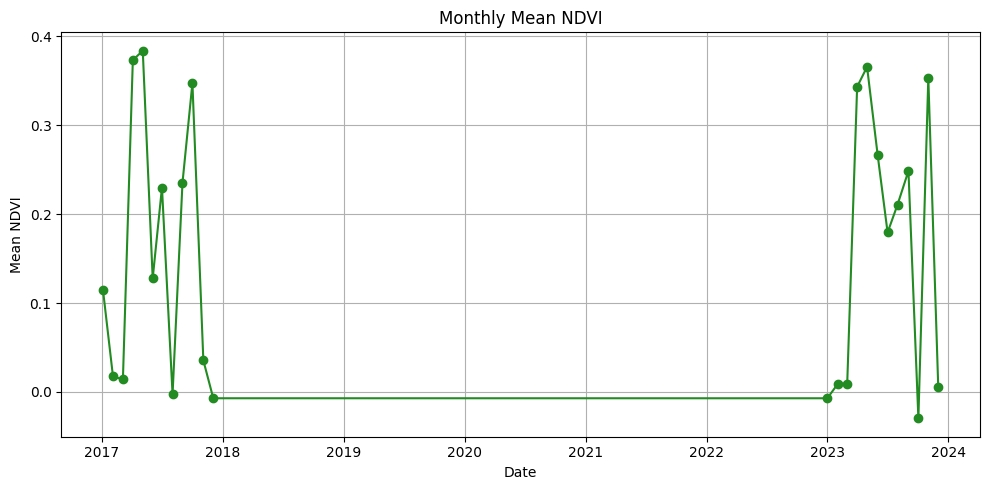

In [4]:
import xarray as xr
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Folder with your .nc files
data_folder = Path("results")  # or "results_thunderbird", etc.

# Collect all NDVI files (edit glob as needed)
nc_files = sorted(data_folder.glob("ndvi_*.nc"))

dates = []
mean_ndvi = []

for f in nc_files:
    ds = xr.open_dataset(f)
    ndvi = ds["var"].isel(t=0)
    avg = float(ndvi.mean().values)
    timestamp = ds.coords["t"].values[0]
    dates.append(np.datetime64(timestamp))
    mean_ndvi.append(avg)
    ds.close()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, mean_ndvi, marker='o', color='forestgreen')
plt.title("Monthly Mean NDVI")
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.grid(True)
plt.tight_layout()
plt.savefig("ndvi_timeseries.png", dpi=300)
plt.show()


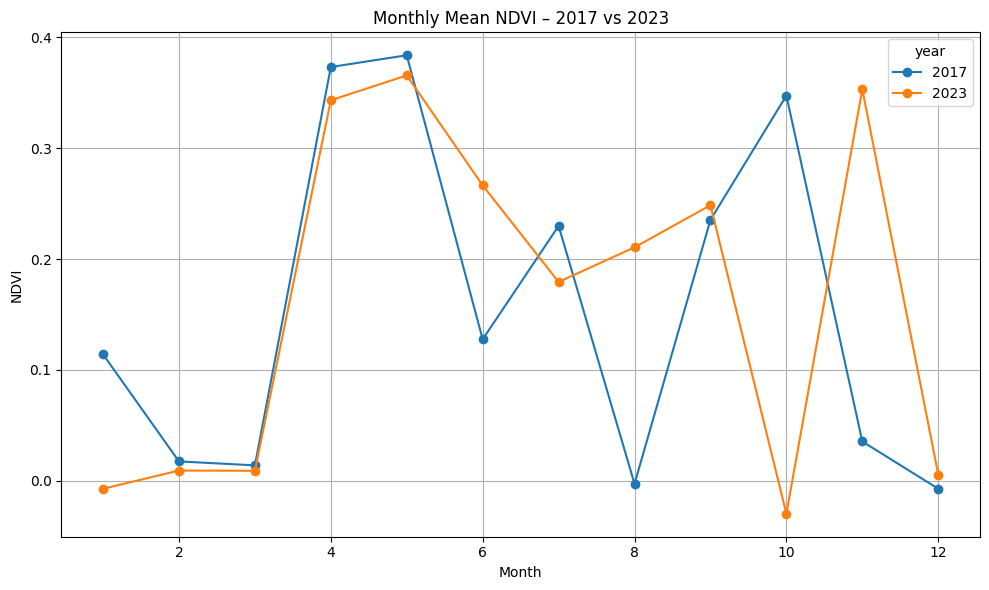

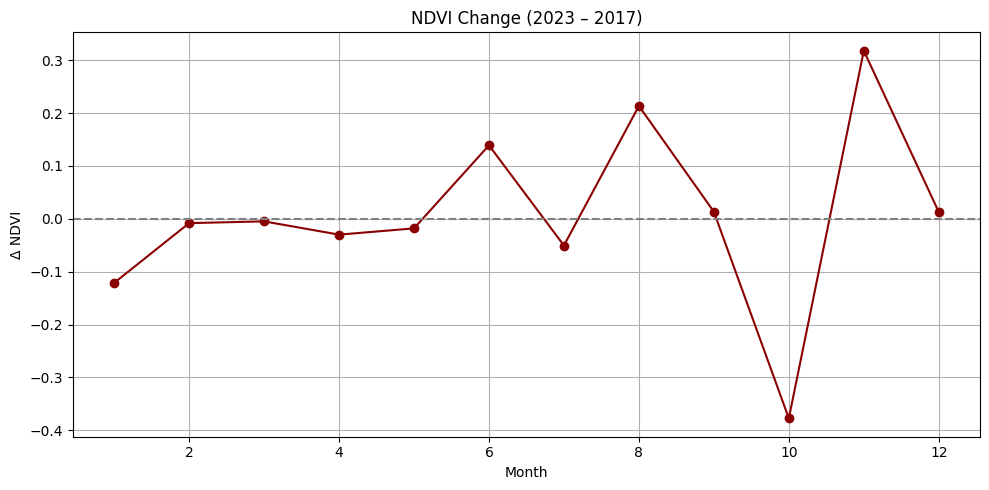

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load into DataFrame
df = pd.DataFrame({"date": dates, "ndvi": mean_ndvi})
df["year"] = pd.DatetimeIndex(df["date"]).year
df["month"] = pd.DatetimeIndex(df["date"]).month

# Step 2: Pivot into year-by-month format
pivot = df.pivot(index="month", columns="year", values="ndvi")

# Step 3: Plot NDVI comparison
pivot.plot(marker='o', figsize=(10, 6), title="Monthly Mean NDVI – 2017 vs 2023")
plt.ylabel("NDVI")
plt.xlabel("Month")
plt.grid(True)
plt.tight_layout()
plt.savefig("ndvi_monthly_comparison_2017_2023.png", dpi=300)
plt.show()

# Step 4: Plot NDVI delta (2023 - 2017)
delta = pivot[2023] - pivot[2017]
delta.plot(marker='o', color='darkred', figsize=(10, 5), title="NDVI Change (2023 – 2017)")
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel("Δ NDVI")
plt.xlabel("Month")
plt.grid(True)
plt.tight_layout()
plt.savefig("ndvi_delta_2023_minus_2017.png", dpi=300)
plt.show()


In [6]:
print("Annual NDVI Comparison")
print("2017 Mean:", pivot[2017].mean())
print("2023 Mean:", pivot[2023].mean())
print("Change:", pivot[2023].mean() - pivot[2017].mean())

print("\nMonths where NDVI > 0.3")
print("2017:", (pivot[2017] > 0.3).sum(), "months")
print("2023:", (pivot[2023] > 0.3).sum(), "months")


Annual NDVI Comparison
2017 Mean: 0.15572734790233275
2023 Mean: 0.1628669963295882
Change: 0.007139648427255452

Months where NDVI > 0.3
2017: 3 months
2023: 3 months


In [9]:

def classify_ndvi(ndvi):
    return xr.where(ndvi < 0.1, 0,  # Low
           xr.where(ndvi < 0.3, 1,  # Medium
           2))                      # High

ds_2017 = xr.open_dataset("results/ndvi_2017_06.nc")  # June example
ds_2023 = xr.open_dataset("results/ndvi_2023_06.nc")
ndvi_2017 = ds_2017["var"].isel(t=0)
ndvi_2023 = ds_2023["var"].isel(t=0)

cat_2017 = classify_ndvi(ndvi_2017)
cat_2023 = classify_ndvi(ndvi_2023)

mask = (~np.isnan(cat_2017)) & (~np.isnan(cat_2023))
y1 = cat_2017.values[mask].flatten()
y2 = cat_2023.values[mask].flatten()

from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y1, y2)
print(f"Cohen's Kappa (NDVI Class Agreement, June): {kappa:.3f}")


Cohen's Kappa (NDVI Class Agreement, June): 0.202


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


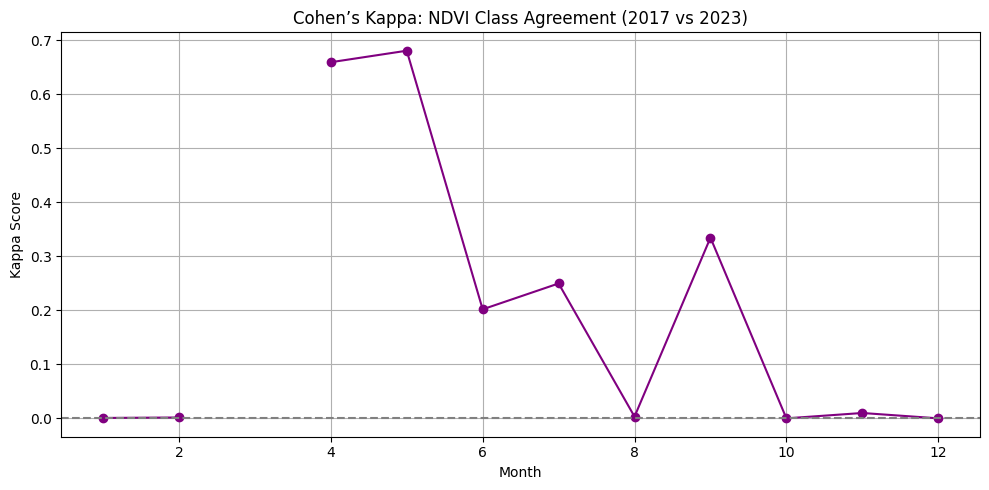

In [10]:
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pathlib import Path

def classify_ndvi(ndvi):
    return xr.where(ndvi < 0.1, 0,
           xr.where(ndvi < 0.3, 1, 2))

base_dir = Path("results")  # adjust to your folder

kappas = []
months = []

for i in range(1, 13):
    fname_2017 = base_dir / f"ndvi_2017_{i:02d}.nc"
    fname_2023 = base_dir / f"ndvi_2023_{i:02d}.nc"
    if not fname_2017.exists() or not fname_2023.exists():
        continue

    ndvi_2017 = xr.open_dataset(fname_2017)["var"].isel(t=0)
    ndvi_2023 = xr.open_dataset(fname_2023)["var"].isel(t=0)

    c1 = classify_ndvi(ndvi_2017)
    c2 = classify_ndvi(ndvi_2023)

    mask = (~np.isnan(c1)) & (~np.isnan(c2))
    y1 = c1.values[mask].flatten()
    y2 = c2.values[mask].flatten()

    k = cohen_kappa_score(y1, y2)
    kappas.append(k)
    months.append(i)

# Plot monthly Kappa scores
plt.figure(figsize=(10, 5))
plt.plot(months, kappas, marker='o', color='purple')
plt.title("Cohen’s Kappa: NDVI Class Agreement (2017 vs 2023)")
plt.xlabel("Month")
plt.ylabel("Kappa Score")
plt.axhline(0, linestyle="--", color="gray")
plt.grid(True)
plt.tight_layout()
plt.savefig("ndvi_kappa_timeseries.png", dpi=300)
plt.show()


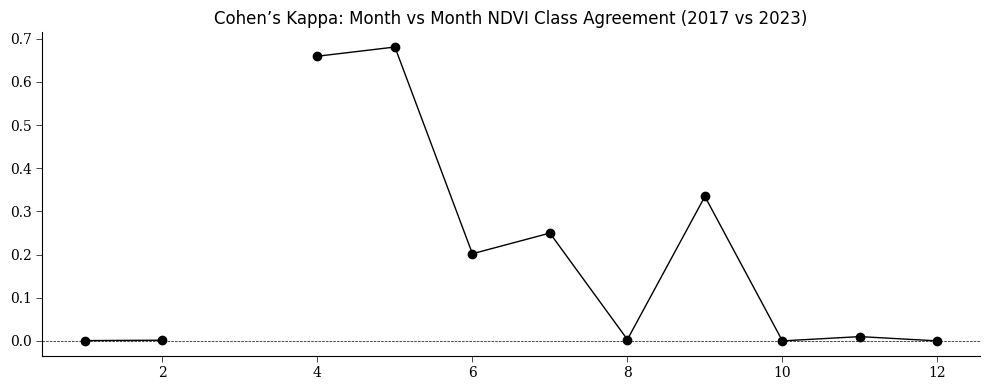

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(months, kappas, marker='o', color='black', linewidth=1)

# Axis labels with serif font


# Title removed for minimalism
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Slight outward tick marks
ax.tick_params(direction='out', length=4, width=0.5)

# Use subtle ticks and serif font
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontfamily("serif")
    label.set_fontsize(10)

plt.title("Cohen’s Kappa: Month vs Month NDVI Class Agreement (2017 vs 2023)")
plt.tight_layout()
plt.savefig("ndvi_kappa_minimalist.png", dpi=300)
plt.show()


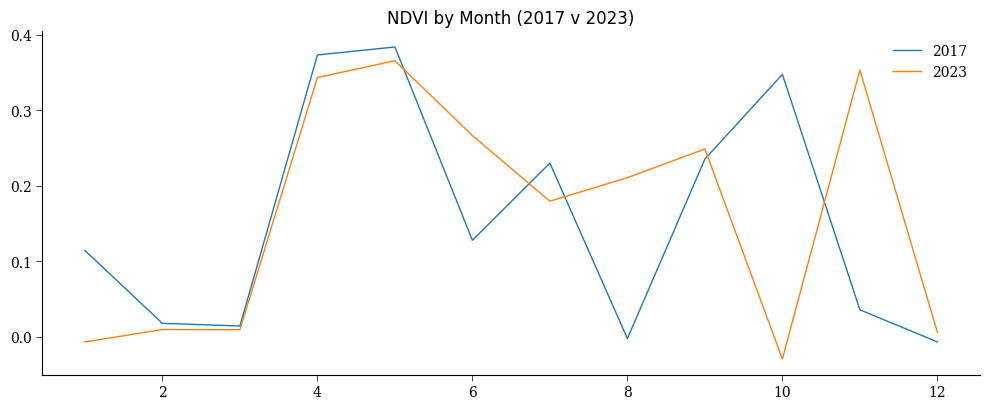

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare DataFrame
df = pd.DataFrame({"date": dates, "ndvi": mean_ndvi})
df["year"] = pd.DatetimeIndex(df["date"]).year
df["month"] = pd.DatetimeIndex(df["date"]).month
pivot = df.pivot(index="month", columns="year", values="ndvi")

# Minimalist comparison plot
fig, ax = plt.subplots(figsize=(10, 4))
for year in pivot.columns:
    ax.plot(pivot.index, pivot[year], linewidth=1, label=str(year))



# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Outward ticks
ax.tick_params(direction='out', length=4, width=0.5)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontfamily("serif")
    label.set_fontsize(10)

ax.legend(frameon=False, prop={"family": "serif", "size": 10})
plt.tight_layout()
plt.title("NDVI by Month (2017 v 2023)")

plt.savefig("ndvi_monthly_comparison_2017_2023_minimalist.png", dpi=300)
plt.show()
